# Employee Attrition Prediction

## Project Overview

Employee attrition refers to employees leaving an organization voluntarily or involuntarily. High employee turnover can increase recruitment costs, reduce productivity, and affect organizational performance.

The objective of this project is to build a machine learning classification model that predicts whether an employee is likely to leave the company based on factors such as age, job role, monthly income, overtime, job satisfaction, work-life balance, and years at the company.

### Target Variable
- `Attrition = Yes` → Employee left the company
- `Attrition = No` → Employee stayed in the company

### Project Workflow
1. Data Understanding
2. Exploratory Data Analysis
3. Data Cleaning
4. Data Preprocessing
5. Feature Selection
6. Train-Test Split
7. Model Training
8. Model Evaluation
9. Model Selection
10. Model Deployment

## 1. Import Required Libraries

Import the necessary Python libraries for data manipulation, numerical operations, and data visualization.

In [1]:
# Import libraries for data manipulation
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## 2. Load the Dataset

Load the IBM HR Analytics Employee Attrition dataset into a Pandas DataFrame.

In [2]:
# Load the employee attrition dataset
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

## 3. Data Understanding

In this section, we explore the dataset to understand its structure, features, data types, and overall characteristics before performing data cleaning and analysis.

### Preview the Dataset

Display the first five rows of the dataset to get an initial understanding of the features and values.

In [3]:
# Display the first 5 rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Dataset Shape

Check the number of rows and columns present in the dataset.

In [4]:
# Check dataset dimensions
df.shape

(1470, 35)

**Observation:**  
The dataset contains **1,470 employee records and 35 columns**.

### Dataset Columns

Display all column names to understand the available employee features.

In [5]:
# Display all column names
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

### Dataset Information

Check the data types and non-null values of all columns.

In [6]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### 3.1 Statistical Summary

Generate descriptive statistics for the numerical columns to understand their distribution, range, mean, and variability.

In [7]:
# Display statistical summary of numerical features
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Observation:**  
The statistical summary provides information about the distribution of numerical employee features such as age, income, work experience, job satisfaction, and years at the company.

### 3.2 Missing Values

Check whether the dataset contains any missing values that need to be handled before model building.

In [8]:
# Check missing values in each column
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


**Observation:**  
The dataset contains no missing values, so no missing-value treatment is required.

### 3.3 Duplicate Records

Check for duplicate employee records that could affect the analysis and model performance.

In [9]:
# Check the number of duplicate rows
df.duplicated().sum()

np.int64(0)

**Observation:**  
There are no duplicate records in the dataset.

### 3.4 Unique Values

Check the number of unique values in each column to identify categorical features and columns with constant values.

In [10]:
# Check unique values in each column
df.nunique()

,0
Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1
EmployeeNumber,1470


### 3.5 Target Variable Distribution

Examine the distribution of the `Attrition` target variable to understand how many employees stayed and how many left the company.

In [11]:
# Check the distribution of the target variable
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [12]:
# Check target distribution in percentage
df['Attrition'].value_counts(normalize=True) * 100

,proportion
Attrition,
No,83.877551
Yes,16.122449


**Observation:**  
Approximately **83.9%** of employees stayed with the company, while **16.1%** experienced attrition. This indicates that the target variable is imbalanced, which should be considered during model evaluation.

## 4. Data Cleaning

In this section, unnecessary or non-informative columns are identified and removed to prepare the dataset for further analysis and model building.

### 4.1 Identify Constant Columns

Columns containing the same value for every employee do not provide useful information for predicting attrition.

In [13]:
# Display columns having only one unique value
constant_columns = [col for col in df.columns if df[col].nunique() == 1]

constant_columns

['EmployeeCount', 'Over18', 'StandardHours']

**Observation:**  
`EmployeeCount`, `Over18`, and `StandardHours` contain only one unique value across all employee records. Therefore, these columns do not contribute useful information for attrition prediction.

### 4.2 Check Employee Number

In [14]:
# Check the number of unique EmployeeNumber values
df['EmployeeNumber'].nunique()

1470

**Observation:**  
`EmployeeNumber` contains a unique identifier for each employee. Since it only identifies individual records and does not represent an employee characteristic, it is not useful for predicting attrition.

### 4.3 Remove Unnecessary Columns

Remove constant columns and the employee identifier column because they do not provide meaningful predictive information.

In [15]:
# Remove non-informative and identifier columns
df.drop(
    columns=['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'],
    inplace=True
)

# Check the updated dataset shape
df.shape

(1470, 31)

**Observation:**  
After removing 4 unnecessary columns, the dataset now contains **1,470 rows and 31 columns**.

## 5. Exploratory Data Analysis (EDA)

In this section, the dataset is explored visually to identify patterns and relationships between employee characteristics and attrition.

### 5.1 Attrition Distribution

Visualize the distribution of employees who stayed and employees who left the organization.

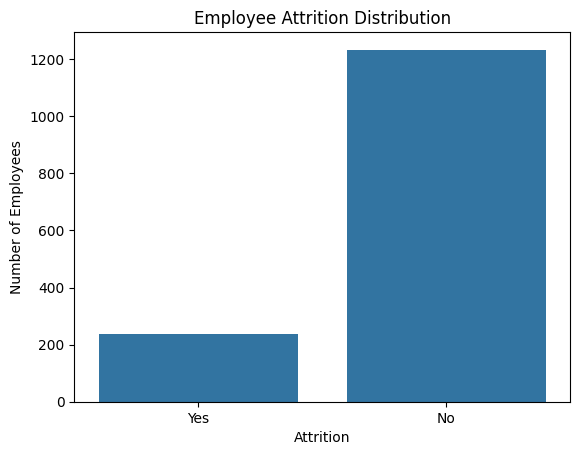

In [16]:
# Visualize attrition distribution
sns.countplot(data=df, x='Attrition')

plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.show()

**Observation:**  
Most employees stayed with the organization, while a smaller proportion experienced attrition. This confirms that the target variable is imbalanced.

### 5.2 Attrition by OverTime

Analyze whether employees who work overtime show a higher tendency to leave the organization.

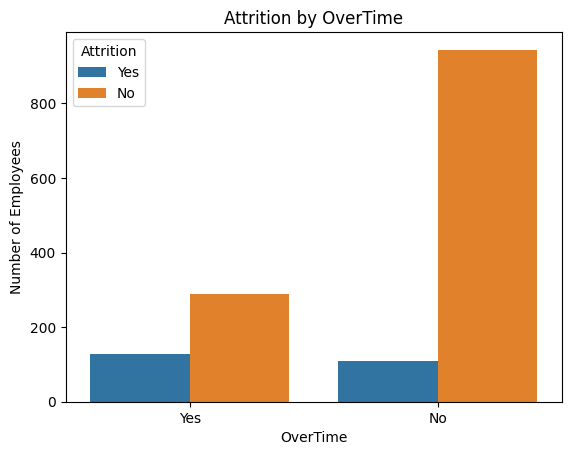

In [17]:
# Compare attrition based on overtime
sns.countplot(data=df, x='OverTime', hue='Attrition')

plt.title('Attrition by OverTime')
plt.xlabel('OverTime')
plt.ylabel('Number of Employees')
plt.show()

**Observation:**  
Employees who work overtime appear to have a higher proportion of attrition compared with employees who do not work overtime.

### 5.3 Age Distribution by Attrition

Compare the age distribution of employees who stayed and employees who left the organization.

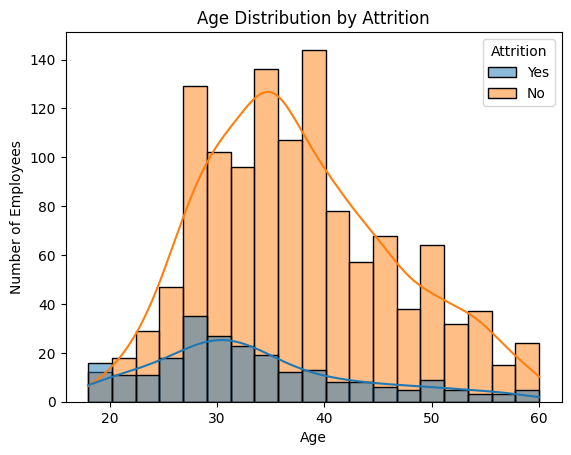

In [18]:
# Compare age distribution based on attrition
sns.histplot(
    data=df,
    x='Age',
    hue='Attrition',
    kde=True,
    multiple='layer'
)

plt.title('Age Distribution by Attrition')
plt.xlabel('Age')
plt.ylabel('Number of Employees')
plt.show()

**Observation:**  
Attrition is observed across different age groups, with younger employees appearing more frequently among employees who left the organization.

### 5.4 Monthly Income by Attrition

Analyze whether monthly income differs between employees who stayed and employees who left the organization.

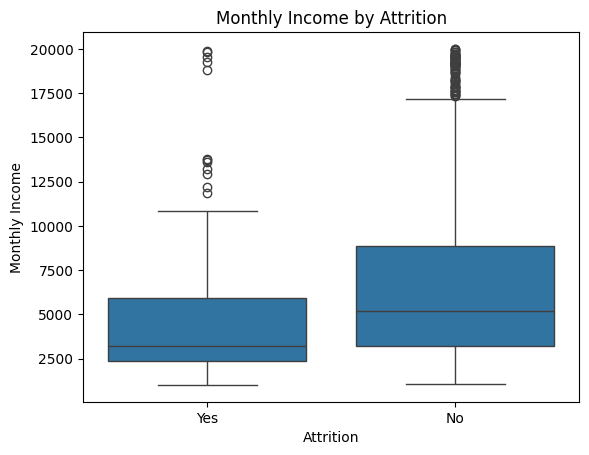

In [19]:
# Compare monthly income based on attrition
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')

plt.title('Monthly Income by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.show()

**Observation:**  
Employees who experienced attrition generally appear to have lower monthly income compared with employees who stayed.

### 5.5 Job Satisfaction vs Attrition

Analyze the relationship between employee job satisfaction levels and attrition.

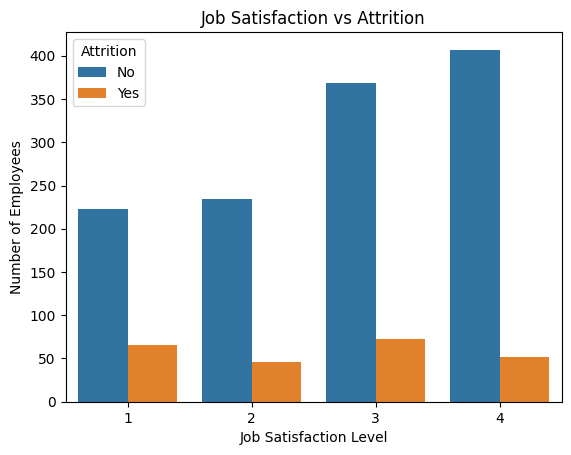

In [20]:
# Compare job satisfaction levels based on attrition
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition')

plt.title('Job Satisfaction vs Attrition')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Number of Employees')
plt.show()

**Observation:**  
Attrition occurs across all job satisfaction levels. Employees with lower job satisfaction show a noticeable tendency toward attrition, although job satisfaction alone does not fully explain employee turnover.

### 5.6 Work-Life Balance vs Attrition

Analyze whether employee work-life balance is associated with attrition.

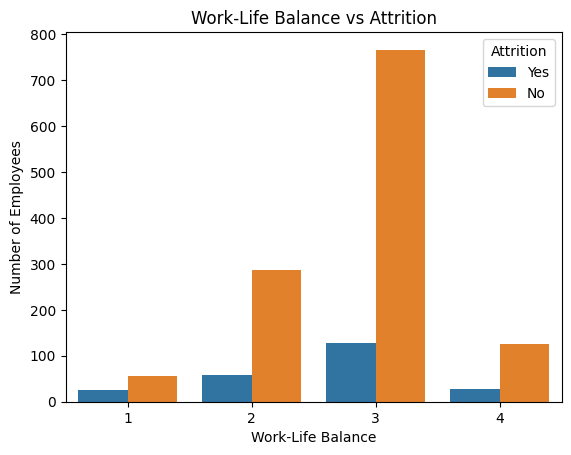

In [21]:
# Compare work-life balance based on attrition
sns.countplot(data=df, x='WorkLifeBalance', hue='Attrition')

plt.title('Work-Life Balance vs Attrition')
plt.xlabel('Work-Life Balance')
plt.ylabel('Number of Employees')
plt.show()

**Observation:**  
Employees with different work-life balance levels experience attrition, with relatively higher attrition visible among employees with poorer work-life balance.

### 5.7 Department vs Attrition

Compare employee attrition across different departments in the organization.

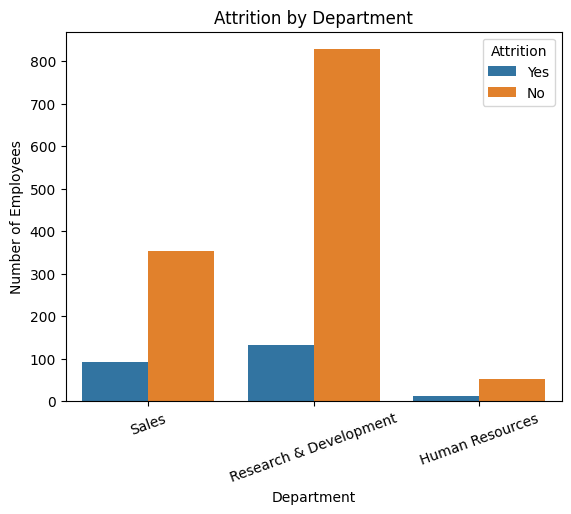

In [22]:
# Compare attrition across departments
sns.countplot(data=df, x='Department', hue='Attrition')

plt.title('Attrition by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=20)
plt.show()

In [23]:
# Calculate attrition rate for each department
department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

department_attrition

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


### 5.8 Job Role vs Attrition

Analyze how employee attrition varies across different job roles.

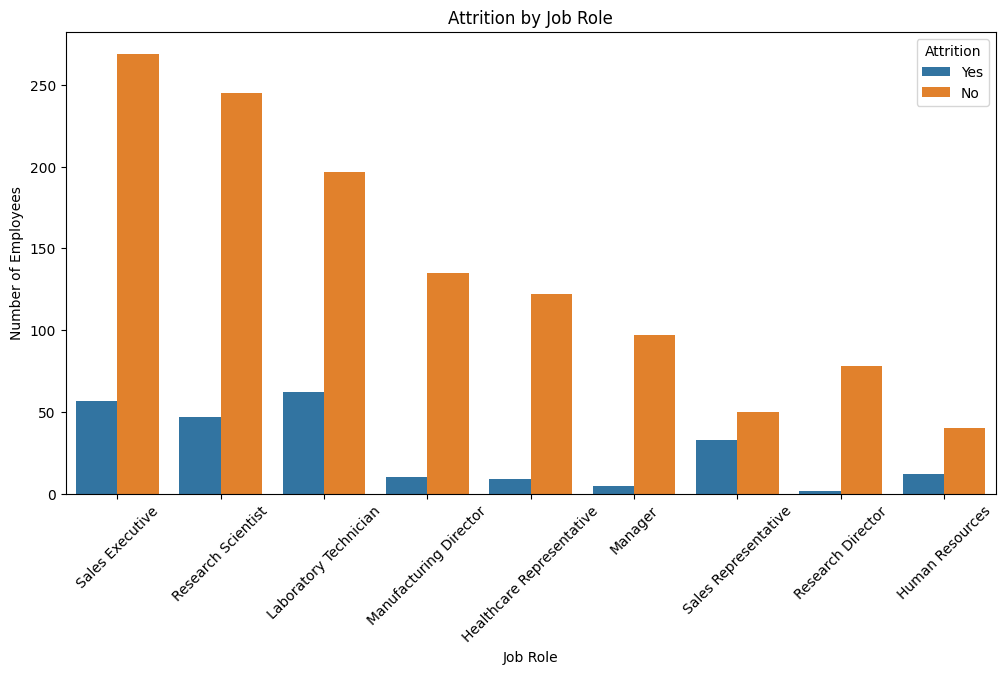

In [24]:
# Compare attrition across different job roles
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x='JobRole', hue='Attrition')

plt.title('Attrition by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)
plt.show()

In [25]:
# Calculate attrition rate for each job role
jobrole_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
) * 100

jobrole_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


### 5.9 Distance From Home vs Attrition

Analyze whether the distance between an employee's home and workplace is associated with attrition.

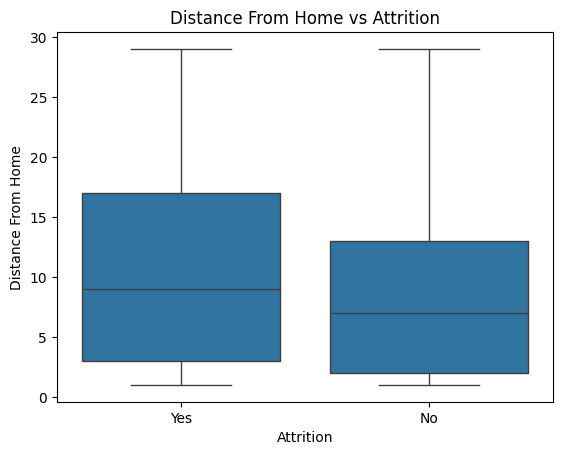

In [26]:
# Compare distance from home based on attrition
sns.boxplot(data=df, x='Attrition', y='DistanceFromHome')

plt.title('Distance From Home vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Distance From Home')
plt.show()

### 5.10 Years at Company vs Attrition

Analyze the relationship between employee tenure at the company and attrition.

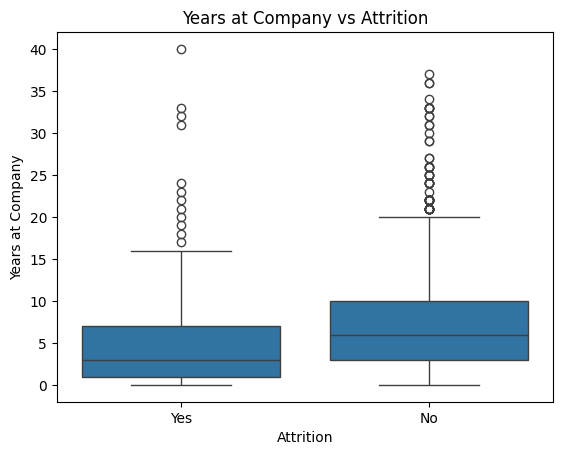

In [27]:
# Compare years at company based on attrition
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany')

plt.title('Years at Company vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Years at Company')
plt.show()

### 5.11 Correlation Analysis

Analyze the correlation between numerical features to identify relationships among employee-related variables.

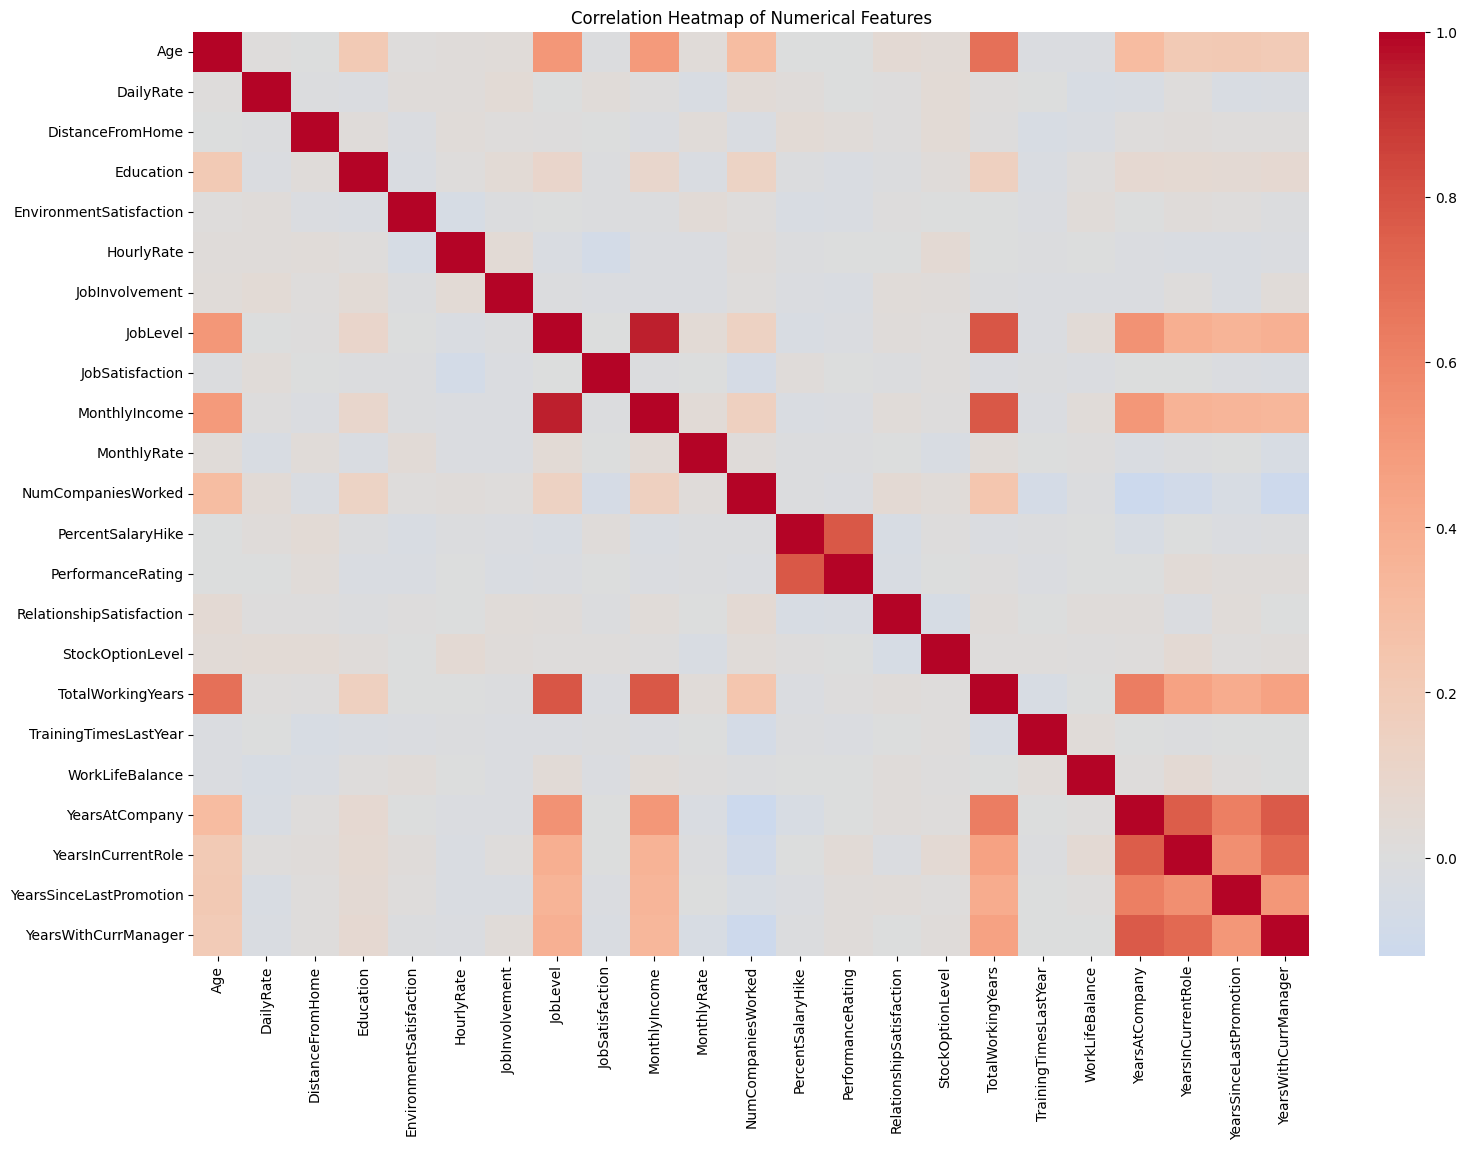

In [28]:
# Select numerical columns
numerical_df = df.select_dtypes(include=np.number)

# Calculate correlation matrix
correlation_matrix = numerical_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(18, 12))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Observation:**  
Several experience-related features show noticeable positive correlations with each other. The heatmap also helps identify relationships among numerical variables that may be useful during model development.

### EDA Summary

The exploratory analysis indicates that employee attrition may be associated with several factors including overtime, age, monthly income, job role, work-life balance, job satisfaction, and years spent at the company.

The target variable is imbalanced, with significantly fewer employees experiencing attrition compared with employees who stayed. Therefore, multiple evaluation metrics should be considered while evaluating the classification model.

## 6. Data Preprocessing

In this section, categorical variables are transformed into numerical format so that they can be used by machine learning algorithms. The target variable is also encoded for classification.

### 6.1 Identify Numerical and Categorical Features

Separate the columns based on their data types to understand which features require categorical encoding.

In [29]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

# Identify categorical columns
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


### 6.2 Encode the Target Variable

The target variable `Attrition` contains categorical values (`Yes` and `No`). Label Encoding is applied to convert these categories into numerical values for machine learning.

In [30]:
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Encode the target variable
df['Attrition'] = le.fit_transform(df['Attrition'])

# Check the encoded values
df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


**Observation:**  
The `Attrition` target variable has been successfully encoded using Label Encoding, where `No = 0` and `Yes = 1`.

In [31]:
# Check remaining categorical columns
categorical_columns = df.select_dtypes(include='object').columns

categorical_columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

### 6.4 Encoding Categorical Features

The remaining categorical input features are converted into numerical form. Ordinal Encoding is used for categorical features with a meaningful order, while One-Hot Encoding is used for nominal features without a natural order.

#### Ordinal Encoding

`BusinessTravel` represents the frequency of employee travel and has a meaningful order. Therefore, Ordinal Encoding is applied to this feature.

In [32]:
# Import OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder

# Create OrdinalEncoder with the travel order
oe = OrdinalEncoder(categories=[['Non-Travel', 'Travel_Rarely', 'Travel_Frequently']])

# Encode BusinessTravel
df[['BusinessTravel']] = oe.fit_transform(df[['BusinessTravel']])

# Check encoded values
df['BusinessTravel'].value_counts()

,count
BusinessTravel,
1.0,1043
2.0,277
0.0,150


**Observation:**  
`BusinessTravel` has been converted into numerical form using Ordinal Encoding based on travel frequency.

### 6.5 One-Hot Encoding

The remaining categorical features do not have a meaningful order. Therefore, One-Hot Encoding is applied to convert these nominal features into numerical form.

In [33]:
# Apply One-Hot Encoding to nominal categorical columns
df = pd.get_dummies(df,columns=['Department','EducationField','Gender','JobRole','MaritalStatus','OverTime'],drop_first=True)

In [34]:
# Check updated dataset shape
df.shape

(1470, 44)

In [35]:
# Check first 5 rows after encoding
df.head()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1.0,1102,1,2,2,94,3,2,...,False,False,False,False,False,True,False,False,True,True
1,49,0,2.0,279,8,1,3,61,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1.0,1373,2,2,4,92,2,1,...,True,False,False,False,False,False,False,False,True,True
3,33,0,2.0,1392,3,4,4,56,3,1,...,False,False,False,False,True,False,False,True,False,True
4,27,0,1.0,591,2,1,1,40,3,1,...,True,False,False,False,False,False,False,True,False,False


**Observation:**  
The nominal categorical features have been converted into numerical columns using One-Hot Encoding. The dataset is now fully numerical and ready for the next preprocessing steps.

### 6.6 Separate Independent and Dependent Variables

Separate the dataset into independent features (`X`) and the target variable (`y`). The `Attrition` column is used as the target variable.

In [36]:
# Independent variables
X = df.drop('Attrition', axis=1)

# Dependent variable
y = df['Attrition']

In [37]:
# Check independent variables
X.head()

,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1.0,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,2.0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1.0,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,2.0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,1.0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [38]:
# Check target variable
y.head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [39]:
# Check shapes of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1470, 43)
y shape: (1470,)


### 6.7 Feature Selection

Feature selection is performed to identify the features that have a significant relationship with the target variable `Attrition`. Since this is a classification problem, `f_classif` is used.

In [40]:
# Import feature selection method for classification
from sklearn.feature_selection import f_classif

In [41]:
# Apply f_classif
f_score, p_value = f_classif(X, y)

In [42]:
# Create DataFrame for feature selection results
feature_selection = pd.DataFrame({
    'Feature': X.columns,
    'F_Score': f_score,
    'P_Value': p_value
})

feature_selection

,Feature,F_Score,P_Value
0,Age,38.175887,8.356308e-10
1,BusinessTravel,24.068022,1.033478e-06
2,DailyRate,4.726640,2.985816e-02
3,DistanceFromHome,8.968277,2.793060e-03
4,Education,1.446308,2.293152e-01
5,EnvironmentSatisfaction,15.855209,7.172339e-05
6,HourlyRate,0.068796,7.931348e-01
7,JobInvolvement,25.241985,5.677065e-07
8,JobLevel,43.215344,6.795385e-11
9,JobSatisfaction,15.890004,7.043067e-05


### 6.7.1 Select Significant Features

In [43]:
# Select features with p-value less than 0.05
selected_features = feature_selection[
    feature_selection['P_Value'] < 0.05
]

selected_features

,Feature,F_Score,P_Value
0,Age,38.175887,8.356308e-10
1,BusinessTravel,24.068022,1.033478e-06
2,DailyRate,4.726640,2.985816e-02
3,DistanceFromHome,8.968277,2.793060e-03
5,EnvironmentSatisfaction,15.855209,7.172339e-05
7,JobInvolvement,25.241985,5.677065e-07
8,JobLevel,43.215344,6.795385e-11
9,JobSatisfaction,15.890004,7.043067e-05
10,MonthlyIncome,38.488819,7.147364e-10
16,StockOptionLevel,28.140501,1.301015e-07


**Observation:**  
Features with a p-value less than `0.05` are considered statistically significant for predicting employee attrition.

### 6.7.2 Keep Selected Features

Only the statistically significant features with a p-value less than `0.05` are retained for model building.

In [44]:
# Keep only significant features
X = X[selected_features['Feature']]

# Check selected features
X.head()

,Age,BusinessTravel,DailyRate,DistanceFromHome,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,StockOptionLevel,...,EducationField_Marketing,EducationField_Technical Degree,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1.0,1102,1,2,3,2,4,5993,0,...,False,False,False,False,False,False,False,False,True,True
1,49,2.0,279,8,3,2,2,2,5130,1,...,False,False,False,False,False,False,False,True,False,False
2,37,1.0,1373,2,4,2,1,3,2090,0,...,False,False,True,False,False,False,False,False,True,True
3,33,2.0,1392,3,4,3,1,3,2909,0,...,False,False,False,False,False,False,False,True,False,True
4,27,1.0,591,2,1,3,1,2,3468,1,...,False,False,True,False,False,False,False,True,False,False


In [45]:
# Check updated shape of independent variables
X.shape

(1470, 28)

**Observation:**  
After feature selection, only statistically significant features are retained for predicting employee attrition.

### 6.8 Train-Test Split

Split the dataset into training and testing sets. The training data is used to train the model, while the testing data is used to evaluate its performance on unseen data.

In [46]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,)

In [47]:
# Check shapes of training and testing data
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1176, 28)
X_test: (294, 28)
y_train: (1176,)
y_test: (294,)


### 6.9 Feature Scaling

Standardization is applied to bring numerical features onto a similar scale. `fit_transform()` is applied to the training data, while only `transform()` is applied to the testing data to avoid data leakage.

In [48]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
sc = StandardScaler()

In [49]:
# Fit and transform training data
X_train = sc.fit_transform(X_train)

# Transform testing data
X_test = sc.transform(X_test)

**Observation:**  
The training and testing features have been standardized using `StandardScaler`. The scaler is fitted only on the training data and the same transformation is applied to the testing data.

## 7. Model Building

### 7.1 Logistic Regression

Logistic Regression is applied to predict employee attrition. Since the target variable contains two classes (`0 = No` and `1 = Yes`), this is a binary classification problem.

In [50]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
model = LogisticRegression()

### 7.2 Train the Model

Train the Logistic Regression model using the training dataset.

In [51]:
# Train the model
model.fit(X_train, y_train)

LogisticRegression()

### 7.3 Model Prediction

Use the trained model to predict attrition for both training and testing data.

In [52]:
# Predict training data
y_train_pred = model.predict(X_train)

# Predict testing data
y_test_pred = model.predict(X_test)

### 7.4 Model Accuracy

Calculate and compare the training and testing accuracy of the Logistic Regression model.

In [53]:
# Import accuracy score
from sklearn.metrics import accuracy_score

# Calculate training accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)

# Calculate testing accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy :", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy : 0.8792517006802721
Testing Accuracy : 0.891156462585034


**Observation:**  
The Logistic Regression model achieved approximately **87.93% training accuracy** and **89.12% testing accuracy**. The training and testing accuracies are close to each other, indicating that the model generalizes well and does not show significant overfitting.

### 7.5 Confusion Matrix

The confusion matrix is used to evaluate the classification model by comparing the actual and predicted attrition classes.

In [54]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

cm

array([[247,   8],
       [ 24,  15]])

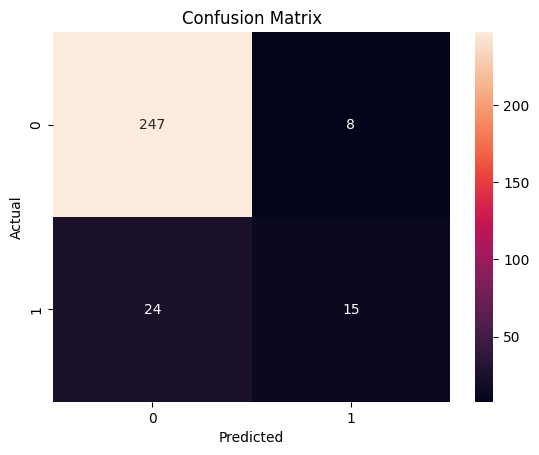

In [55]:
# Visualize confusion matrix
sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Observation:**  
The confusion matrix shows how many employees were correctly and incorrectly classified into the attrition and non-attrition categories.

**Observation:**  
The model correctly predicted **247 employees who stayed** and **15 employees who left**. However, it incorrectly classified **24 employees who actually left** as employees who would stay. This indicates that although the overall accuracy is high, the model has difficulty identifying some employees who are likely to leave.

### 7.6 Classification Report

The classification report is used to evaluate the model using precision, recall, F1-score, and support for both attrition classes.

In [56]:
# Import classification report
from sklearn.metrics import classification_report

# Display classification report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       255
           1       0.65      0.38      0.48        39

    accuracy                           0.89       294
   macro avg       0.78      0.68      0.71       294
weighted avg       0.88      0.89      0.88       294



**Observation:**  
The model performs very well for employees who stay, with a recall of **97%** for class `0`. However, for employees who leave, the recall is only **38%**, which means the model is missing a significant number of actual attrition cases. Therefore, despite the high overall accuracy of **89%**, the model needs improvement in identifying employees who are likely to leave.

### 7.7 ROC Curve and AUC Score

The ROC curve is used to evaluate the model's ability to distinguish between employees who stay and employees who leave. The AUC score summarizes the overall classification performance.

In [57]:
# Import ROC metrics
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability of class 1
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.7721468074409251


**Observation:**  
The Logistic Regression model achieved an AUC score of approximately **0.77**, indicating a good ability to distinguish between employees who stay and employees who leave the organization. However, the relatively low recall for the attrition class shows that the model still misses several employees who actually leave.

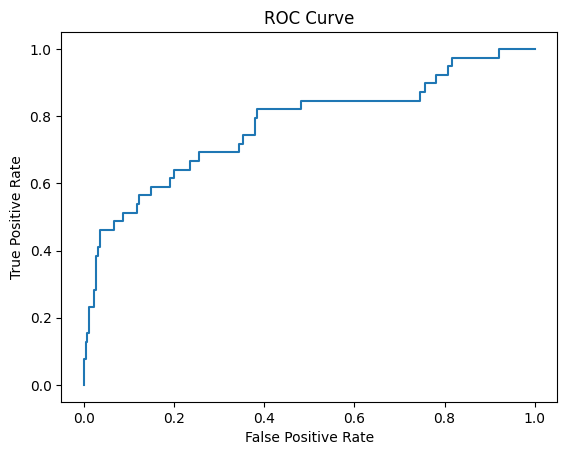

In [58]:
# Plot ROC curve
plt.plot(fpr, tpr)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

## 8. Support Vector Classifier (SVC)

Support Vector Classifier is applied as another classification model to predict employee attrition. Its performance will be compared with the Logistic Regression model.

In [59]:
# Import Support Vector Classifier
from sklearn.svm import SVC

# Create SVC model
svc_model = SVC()

# Train the model
svc_model.fit(X_train, y_train)

SVC()

### 8.2 Model Prediction

Use the trained SVC model to predict attrition for both training and testing data.

In [60]:
# Predict training data
y_train_pred_svc = svc_model.predict(X_train)

# Predict testing data
y_test_pred_svc = svc_model.predict(X_test)

### 8.3 Model Accuracy

Calculate the training and testing accuracy of the SVC model to evaluate its performance.

In [61]:
# Calculate training and testing accuracy
train_accuracy_svc = accuracy_score(y_train, y_train_pred_svc)
test_accuracy_svc = accuracy_score(y_test, y_test_pred_svc)

print("SVC Training Accuracy:", train_accuracy_svc)
print("SVC Testing Accuracy:", test_accuracy_svc)

SVC Training Accuracy: 0.9013605442176871
SVC Testing Accuracy: 0.8877551020408163


**Observation:**  
The SVC model achieved approximately **90.14% training accuracy** and **88.78% testing accuracy**. The training and testing accuracies are close, indicating that the model does not show significant overfitting. Its testing accuracy is slightly lower than the Logistic Regression model.

In [62]:
# Create confusion matrix for SVC
cm_svc = confusion_matrix(y_test, y_test_pred_svc)

cm_svc

array([[251,   4],
       [ 29,  10]])

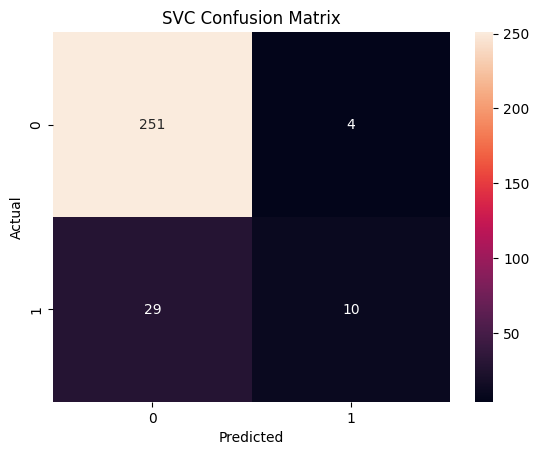

In [63]:
# Visualize SVC confusion matrix
sns.heatmap(cm_svc, annot=True, fmt='d')

plt.title('SVC Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [64]:
# Display SVC classification report
print(classification_report(y_test, y_test_pred_svc))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       255
           1       0.71      0.26      0.38        39

    accuracy                           0.89       294
   macro avg       0.81      0.62      0.66       294
weighted avg       0.87      0.89      0.86       294



**Observation:**  
The SVC model achieved high overall accuracy, but its recall for the attrition class is only **26%**, meaning it misses many employees who actually leave. Compared with SVC, Logistic Regression provides better recall and F1-score for the attrition class and also has slightly higher testing accuracy. Therefore, Logistic Regression performs better for this employee attrition prediction task.

## 9. Model Comparison

The performance of Logistic Regression and Support Vector Classifier (SVC) is compared to select the most suitable model for employee attrition prediction.

In [65]:
# Create model comparison table
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVC'],
    'Training Accuracy': [train_accuracy, train_accuracy_svc],
    'Testing Accuracy': [test_accuracy, test_accuracy_svc],
    'Attrition Precision': [0.65, 0.71],
    'Attrition Recall': [0.38, 0.26],
    'Attrition F1-Score': [0.48, 0.38]
})

model_comparison

,Model,Training Accuracy,Testing Accuracy,Attrition Precision,Attrition Recall,Attrition F1-Score
0,Logistic Regression,0.879252,0.891156,0.65,0.38,0.48
1,SVC,0.901361,0.887755,0.71,0.26,0.38


### Final Model Selection

**Logistic Regression** is selected as the final model for deployment.

Although both models achieved similar overall accuracy, Logistic Regression achieved better testing accuracy, recall, and F1-score for the attrition class. Since identifying employees who are likely to leave is the primary objective of this project, Logistic Regression is more suitable for the final prediction system.

## 10. Save the Trained Model

The final Logistic Regression model and the fitted StandardScaler are saved using `pickle`. These files will be loaded later in the deployment application so that the model can make predictions without being trained again.

In [66]:
# Import pickle
import pickle

# Save the trained model
with open('employee_attrition_model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [67]:
# Save the StandardScaler
with open('scaler.pkl', 'wb') as file:
    pickle.dump(sc, file)

**Observation:**  
The trained Logistic Regression model and StandardScaler have been successfully saved for deployment.

## 11. Prepare Features for Deployment

The deployment application must provide input features in the same order and format used during model training. Therefore, the final selected feature names are stored for reference.

In [68]:
# Display final selected features used by the model
X.columns

Index(['Age', 'BusinessTravel', 'DailyRate', 'DistanceFromHome',
       'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Marketing', 'EducationField_Technical Degree',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_Research Director',
       'JobRole_Sales Representative', 'MaritalStatus_Married',
       'MaritalStatus_Single', 'OverTime_Yes'],
      dtype='object')

In [69]:
# Save final feature names
with open('feature_names.pkl', 'wb') as file:
    pickle.dump(X.columns, file)

**Observation:**  
The final feature names used during model training have been saved so that the deployment application can maintain the same input structure.